In [1]:
import pandas as pd
import seaborn as sns
import treedata
import pickle
import matplotlib.pyplot as plt

import numpy as np
from tqdm.notebook import tqdm

In [20]:
!ls ../lt/data/

annotation_v5.csv	   hvg_v5.csv
c_elegans.h5ad		   kl0.01_d50_l2_covnocov_adata_with_embeddings.h5ad
E75-E95_annotated_v1.h5td  kl0.0_d50_l2_covnocov_adata_with_embeddings.h5ad
E95_annotated_v3.h5td	   LTSeq_preprocessed.h5ad
E95_annotated_v4_obs.csv   mm39_annotations.csv
embryos			   packer_lineage_tree.gml
embryo_tree_cache.pkl	   qiu2022_combined.h5ad
fast_concat.ipynb	   qiu2022_integrated_scvi.h5ad
final_subtype.csv	   stateFate_inVitro_clone_matrix.mtx
final_type_info.csv	   stateFate_inVitro_gene_names.txt
final_umap.csv		   stateFate_inVitro_metadata.txt
gene_symbols.tsv	   stateFate_inVitro_neutrophil_pseudotime.txt
gokul@vort.wi.mit.edu	   stateFate_inVitro_normed_counts.mtx


In [21]:
umap_coords = pd.read_csv('/home/gokulg/orcd/scratch/lt/data/final_umap.csv', index_col=0)
cell_types = pd.read_csv('/home/gokulg/orcd/scratch/lt/data/final_subtype.csv', index_col=0)
type_info = pd.read_csv('/home/gokulg/orcd/scratch/lt/data/final_type_info.csv', index_col=0)

type_info.head(3)

,cell_type,cluster,lineage,germ_layer,type_color,id,subtype_id,subtype_color
cell_subtype,,,,,,,,
rostral ectoderm,rostral ectoderm,early,ectoderm,ectoderm,#a05837,1,1,#a05837
amniotic ectoderm,amniotic ectoderm,extraembryonic and pgc,extraembryonic ectoderm,ectoderm,#c0b9b2,2,2,#c0b9b2
extraembryonic ectoderm,extraembryonic ectoderm,extraembryonic and pgc,extraembryonic ectoderm,ectoderm,#bc23ff,3,3,#bc23ff


In [25]:
cell_types.head(3)

,cell_subtype
E10.0-R1-T21-TCGGCAACATAATTCC-1,dorsal root ganglion neuron
E9.5-R2-T10-GTGGCAGGTCATGGCC-1,primitive erythrocyte
E9.5-R2-T16-AAGTCATTCATCGTGA-1,somatic mesoderm (posterior)


In [26]:
name_to_subtype = {name: cell_types.loc[name, 'cell_subtype'] for name in cell_types.index}
subtype_to_lineage = {subtype: type_info.loc[subtype, 'lineage'] for subtype in type_info.index}

In [3]:
node_mmd = pickle.load(open("commitment/node_mmd_dictionary.pkl", "rb"))

In [4]:
adata = treedata.read_h5td('/home/gokulg/orcd/scratch/lt/data/kl0.0_d50_l2_covnocov_adata_with_embeddings.h5ad')

tree_filenames = []
for e in ["7.5", "8.0", "8.5", "9.0", "9.5"]:
    for r in [1, 2, 3]:
        tree_filenames.append(f"e{e}_r{r}_tree")
tree_filenames.append("e10.0_r1_tree")

tdatas = [
    treedata.read_h5td(f"/home/gokulg/orcd/scratch/lt/data/embryos/{f}.h5td")
    for f in tree_filenames
]

trees, tree_names = [], []
for td in tdatas:
    for k in td.obst.keys():
        trees.append(td.obst[k])
        tree_names.append(k)

# Create name->index mapping
name_to_idx = {name: idx for idx, name in enumerate(adata.obs_names)}


In [8]:
results = {}

for tree in tqdm(trees, desc="aggregating MMD results for leaves", total=len(trees)):
    leaves_in_tree = [node for node in tree.nodes() if tree.out_degree(node) == 0 and node in name_to_idx]
    for leaf in tqdm(leaves_in_tree, desc="processing leaves", leave=False):
        if leaf not in node_mmd:
            continue
        mmd_list = [node_mmd[leaf]]  # include leaf's own MMD
        
        # walk up the tree from leaf to root
        current = leaf
        
        # for each ancestor, look up the precomputed MMD
        while list(tree.predecessors(current)):
            parent = list(tree.predecessors(current))[0]
            if parent in node_mmd:
                mmd_list.append(node_mmd[parent])
            current = parent
        
        results[leaf] = mmd_list

# Define threshold as fraction of maximum MMD
threshold_fraction = 0.7

t_threshold_values = []

for leaf in tqdm(adata.obs_names, desc=f"Computing t_{threshold_fraction}"):

    if leaf not in results:
        # If no MMD results for this leaf, set to NaN
        t_threshold_values.append(np.nan)
        continue

    trajectory = results[leaf]
    
    if not trajectory:
        # If no trajectory, set to NaN
        t_threshold_values.append(np.nan)
        continue
    
    mmd_values, times = zip(*trajectory)
    mmd_values = np.array(mmd_values)
    times = np.array(times)
    
    # Find maximum MMD
    max_mmd = np.max(mmd_values)
    
    # Compute threshold
    threshold = threshold_fraction * max_mmd
    
    # Find first time when MMD exceeds threshold
    # Sort by time to ensure we find the earliest occurrence
    sort_idx = np.argsort(times)
    times_sorted = times[sort_idx]
    mmd_sorted = mmd_values[sort_idx]
    
    exceeds_threshold = mmd_sorted >= threshold
    
    if np.any(exceeds_threshold):
        # Find first index where threshold is exceeded
        first_idx = np.argmax(exceeds_threshold)
        t_threshold = times_sorted[first_idx]
    else:
        # Threshold never exceeded
        t_threshold = np.nan
    
    t_threshold_values.append(t_threshold)

# Add to adata.obs with dynamic column name
col_name = f'mmd_t{int(threshold_fraction*100)}'
adata.obs[col_name] = t_threshold_values

aggregating MMD results for leaves:   0%|          | 0/56 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/850 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/181 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/766 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/199 [00:00<?, ?it/s]

...

processing leaves:   0%|          | 0/49189 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/11966 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/9587 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/5467 [00:00<?, ?it/s]

Computing t_0.7:   0%|          | 0/1795384 [00:00<?, ?it/s]

df constructed
aggregation done, plotting


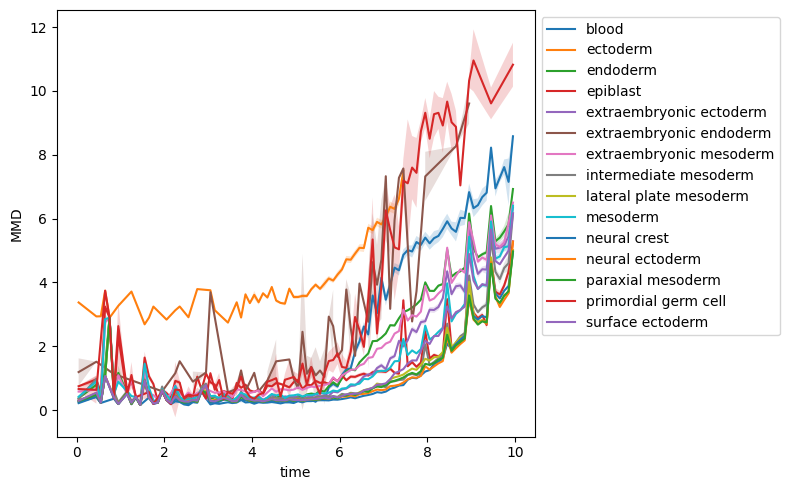

In [30]:
name_to_lineage = {name: subtype_to_lineage[name_to_subtype[name]] for name in adata.obs_names}

# Build a long-form DataFrame: one row per (cell, ancestor) with time, mmd, lineage
rows = []
for leaf, trajectory in results.items():
    lineage = name_to_lineage.get(leaf, "Unknown")
    for mmd_val, t in trajectory:
        rows.append((t, mmd_val, lineage))

df = pd.DataFrame(rows, columns=["time", "mmd", "lineage"])

print('df constructed')
# Bin continuous time into equal-width bins, then compute running mean per lineage
n_bins = 100
df["time_bin"] = pd.cut(df["time"], bins=n_bins, labels=False)
# Use bin midpoints as x values
bin_edges = pd.cut(df["time"], bins=n_bins).cat.categories
df["time_mid"] = df["time_bin"].map(lambda i: bin_edges[int(i)].mid if pd.notna(i) else np.nan)

# Aggregate: mean + std per (lineage, time_bin), much faster than bootstrap CI on 1M rows
agg = df.groupby(["lineage", "time_mid"], observed=True)["mmd"].agg(["mean", "std", "count"]).reset_index()
agg["se"] = agg["std"] / np.sqrt(agg["count"])

print('aggregation done, plotting')

fig, ax = plt.subplots(figsize=(8, 5))
for lineage, grp in agg.groupby("lineage"):
    grp = grp.sort_values("time_mid")
    ax.plot(grp["time_mid"], grp["mean"], label=lineage)
    ax.fill_between(grp["time_mid"], grp["mean"] - 1.96 * grp["se"], grp["mean"] + 1.96 * grp["se"], alpha=0.2)

ax.set_xlabel("time")
ax.set_ylabel("MMD")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()